In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("Atlantic_United_Kingdom.csv")

In [4]:
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Tattoo,Loreen,89,183374,single,1,False,https://i.scdn.co/image/ab67616d0000b2732b0ba8...
1,18-05-2024,2,Daylight,David Kushner,96,212953,single,1,False,https://i.scdn.co/image/ab67616d0000b27395ca6a...
2,18-05-2024,3,Cha Cha Cha,Käärijä,86,175161,single,1,False,https://i.scdn.co/image/ab67616d0000b273e9973a...
3,18-05-2024,4,Miracle (with Ellie Goulding),Calvin Harris & Ellie Goulding,91,186496,single,1,False,https://i.scdn.co/image/ab67616d0000b273c58e22...
4,18-05-2024,5,Queen of Kings,Alessandra,85,147979,single,1,False,https://i.scdn.co/image/ab67616d0000b2732c9eea...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14948 entries, 0 to 14947
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             14948 non-null  object
 1   position         14948 non-null  int64 
 2   song             14948 non-null  object
 3   artist           14948 non-null  object
 4   popularity       14948 non-null  int64 
 5   duration_ms      14948 non-null  int64 
 6   album_type       14948 non-null  object
 7   total_tracks     14948 non-null  int64 
 8   is_explicit      14948 non-null  bool  
 9   album_cover_url  14948 non-null  object
dtypes: bool(1), int64(4), object(5)
memory usage: 1.0+ MB


In [6]:
df.describe(include='all')

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
count,14948,14948.000000,14948,14948,14948.000000,14948.000000,14948,14948.000000,14948,14948
unique,298,NaN,483,254,NaN,NaN,3,NaN,2,374
top,01-03-2025,NaN,Cruel Summer,Taylor Swift,NaN,NaN,album,NaN,False,https://i.scdn.co/image/ab67616d0000b273e85259...
freq,100,NaN,294,1130,NaN,NaN,8264,NaN,10154,466
mean,NaN,25.496789,NaN,NaN,86.641290,198365.573990,NaN,9.856235,NaN,NaN
std,NaN,14.429646,NaN,NaN,11.634917,47404.538144,NaN,10.527208,NaN,NaN
min,NaN,1.000000,NaN,NaN,0.000000,42166.000000,NaN,1.000000,NaN,NaN
25%,NaN,13.000000,NaN,NaN,82.000000,169534.000000,NaN,1.000000,NaN,NaN
50%,NaN,25.000000,NaN,NaN,89.000000,196560.000000,NaN,12.000000,NaN,NaN
75%,NaN,38.000000,NaN,NaN,93.000000,223878.000000,NaN,15.000000,NaN,NaN


In [7]:
df['date'] = pd.to_datetime(
    df['date'],
    format='%d-%m-%Y'
)

In [8]:
df['date'].head()

,date
0,2024-05-18
1,2024-05-18
2,2024-05-18
3,2024-05-18
4,2024-05-18


In [9]:
df['duration_min'] = df['duration_ms'] / 60000

In [10]:
df[['duration_ms','duration_min']].head()

,duration_ms,duration_min
0,183374,3.056233
1,212953,3.549217
2,175161,2.919350
3,186496,3.108267
4,147979,2.466317


In [11]:
print(df['date'].nunique())

298


In [12]:
df['song'].nunique()

483

In [13]:
df['artist'].nunique()

254

In [14]:
top_artists = df['artist'].value_counts().head(20)

top_artists

,count
artist,
Taylor Swift,1130
Olivia Rodrigo,567
Arctic Monkeys,429
Drake,397
Dave & Central Cee,383
Dua Lipa,376
The Killers,273
Tate McRae,266
Doja Cat,262


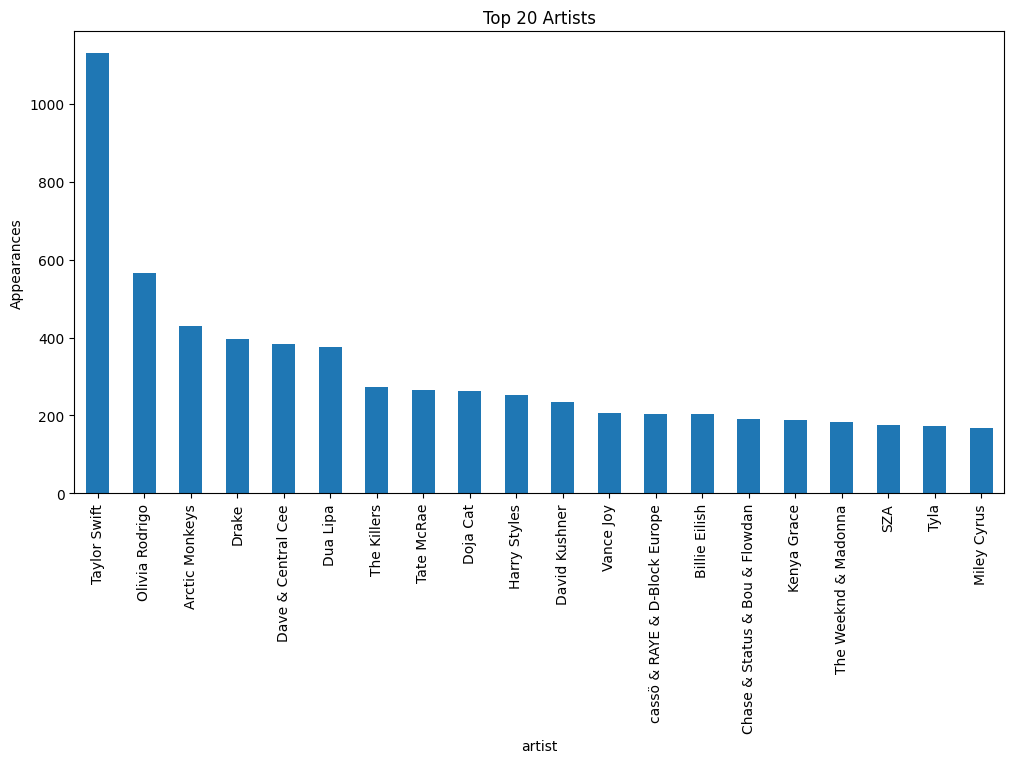

In [15]:
plt.figure(figsize=(12,6))

top_artists.plot(kind='bar')

plt.title("Top 20 Artists")
plt.ylabel("Appearances")

plt.show()

In [16]:
artist_counts = df['artist'].value_counts()

shares = artist_counts / artist_counts.sum()

aci = (shares ** 2).sum()

print("Artist Concentration Index =", round(aci,4))

Artist Concentration Index = 0.0161


In [17]:
top5_share = (
    artist_counts.head(5).sum()
    /
    artist_counts.sum()
) * 100

print("Top 5 Artist Share =", round(top5_share,2), "%")

Top 5 Artist Share = 19.44 %


In [18]:
diversity_score = (
    df['artist'].nunique()
    /
    len(df)
)

print(diversity_score)

0.01699223976451699


In [19]:
df['artist'].sample(20)

,artist
1685,Harry Styles
11370,Fred again..
8311,Taylor Swift
9339,Arctic Monkeys
3320,The Killers
7457,Olivia Rodrigo
7595,Lord Huron
6929,Sonny Fodera & MK & Clementine Douglas
5145,Rema
4034,Post Malone


In [20]:
df['artist'].sample(20).tolist()

['Calvin Harris & Sam Smith',
 'Kanye West',
 'David Guetta & Bebe Rexha',
 'Djo',
 'Hannah Laing & RoRo',
 'Harry Styles',
 'Nicki Minaj & Ice Spice & Aqua',
 'Hannah Laing & RoRo',
 'PinkPantheress & Ice Spice',
 '¥$ & Kanye West & Ty Dolla $ign',
 'Travis Scott & Bad Bunny & The Weeknd',
 'Taylor Swift',
 'D-Block Europe',
 'Jazzy',
 'Taylor Swift',
 'Andy Williams',
 'Kanye West',
 'SZA',
 'Lord Huron',
 'Paul McCartney']

In [23]:
df['artist_list'] = df['artist'].apply(
    lambda x: [i.strip() for i in x.split('&')]
)

In [24]:
df[['artist','artist_list']].head()

,artist,artist_list
0,Loreen,[Loreen]
1,David Kushner,[David Kushner]
2,Käärijä,[Käärijä]
3,Calvin Harris & Ellie Goulding,"[Calvin Harris, Ellie Goulding]"
4,Alessandra,[Alessandra]


In [25]:
df['is_collaboration'] = df['artist_list'].apply(
    lambda x: len(x) > 1
)

In [26]:
df['is_collaboration'].value_counts()

,count
is_collaboration,
False,11665
True,3283


In [27]:
collab_ratio = (
    df['is_collaboration'].sum()
    /
    len(df)
) * 100

print(round(collab_ratio,2))

21.96


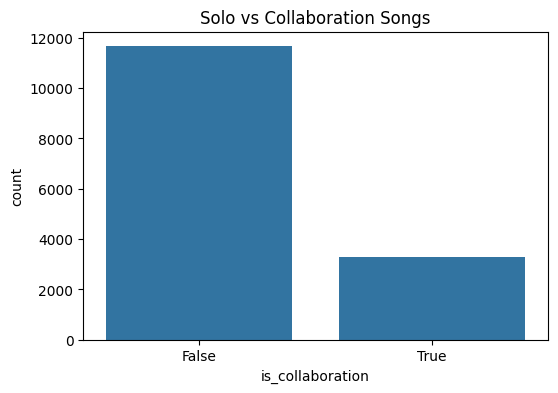

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='is_collaboration',
    data=df
)

plt.title("Solo vs Collaboration Songs")

plt.show()

In [29]:
avg_collab = df['artist_list'].apply(len).mean()

print(round(avg_collab,2))

1.32


In [30]:
top10 = df[df['position'] <= 10]

top10_collab = (
    top10['is_collaboration'].mean()
) * 100

print(round(top10_collab,2))

23.21


In [31]:
df['is_collaboration'].value_counts()

,count
is_collaboration,
False,11665
True,3283


In [32]:
collab_ratio

np.float64(21.962804388546964)

In [33]:
top10_collab

np.float64(23.210702341137125)

In [34]:
df['is_explicit'].value_counts()

,count
is_explicit,
False,10154
True,4794


In [35]:
explicit_share = (
    df['is_explicit'].mean()
) * 100

print(round(explicit_share,2))

32.07


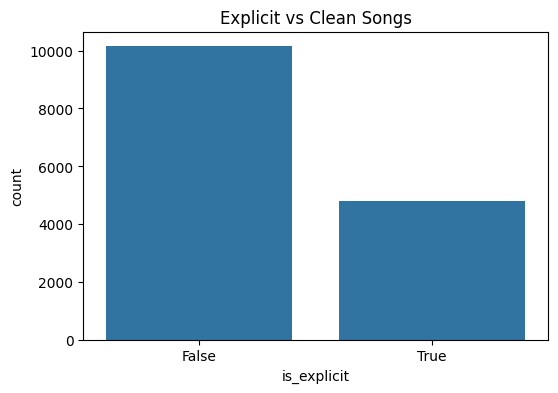

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='is_explicit',
    data=df
)

plt.title("Explicit vs Clean Songs")

plt.show()

In [37]:
df.groupby('is_explicit')['position'].mean()

,position
is_explicit,
False,26.687118
True,22.975594


In [38]:
df['album_type'].value_counts()

,count
album_type,
album,8264
single,6609
compilation,75


In [39]:
album_ratio = (
    df['album_type']
    .value_counts(normalize=True)
    * 100
)

album_ratio

,proportion
album_type,
album,55.284988
single,44.213273
compilation,0.501739


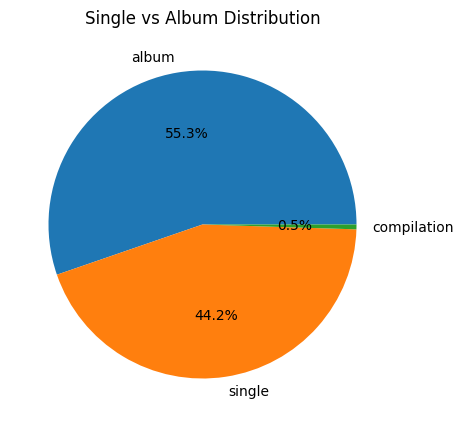

In [40]:
plt.figure(figsize=(7,5))

df['album_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')

plt.title("Single vs Album Distribution")

plt.show()

In [41]:
df.groupby('album_type')['total_tracks'].mean()

,total_tracks
album_type,
album,16.282067
compilation,60.066667
single,1.251475


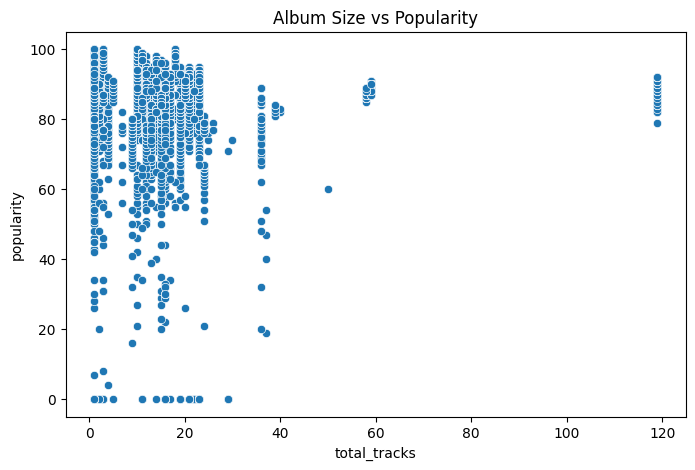

In [42]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='total_tracks',
    y='popularity',
    data=df
)

plt.title("Album Size vs Popularity")

plt.show()

In [43]:
df['duration_min'].describe()

,duration_min
count,14948.000000
mean,3.306093
std,0.790076
min,0.702767
25%,2.825567
50%,3.276000
75%,3.731300
max,9.128883


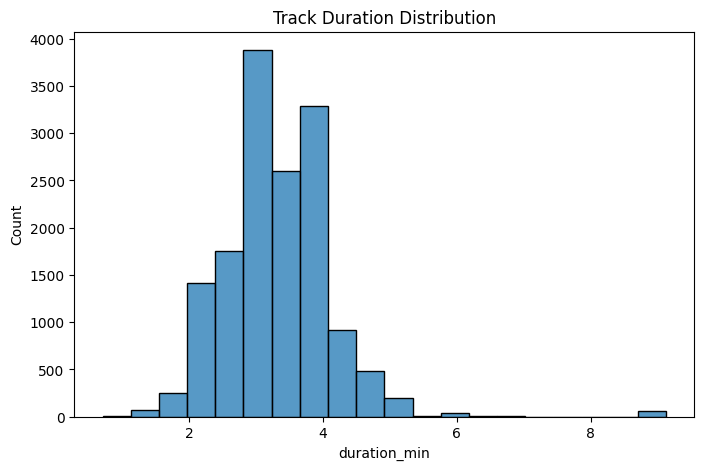

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['duration_min'],
    bins=20
)

plt.title("Track Duration Distribution")

plt.show()

In [45]:
df.groupby(
    pd.cut(
        df['duration_min'],
        bins=[0,3,4,5,20]
    )
).size()

/tmp/ipykernel_2157/2522725608.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


,0
duration_min,
"(0, 3]",5399
"(3, 4]",7457
"(4, 5]",1812
"(5, 20]",280


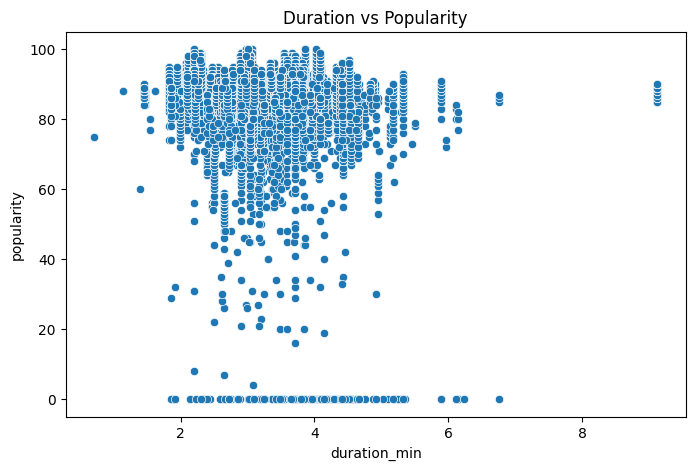

In [46]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='duration_min',
    y='popularity',
    data=df
)

plt.title("Duration vs Popularity")

plt.show()

In [47]:
explicit_share = (
    df['is_explicit'].mean()
) * 100

print(round(explicit_share,2))

32.07


In [48]:
content_variety_index = (
    df['artist'].nunique()
    /
    len(df)
) * 100

print(round(content_variety_index,2))

1.7


In [49]:
import networkx as nx

In [50]:
G = nx.Graph()

for artists in df['artist_list']:

    for i in range(len(artists)):
        for j in range(i+1,len(artists)):

            G.add_edge(
                artists[i].strip(),
                artists[j].strip()
            )

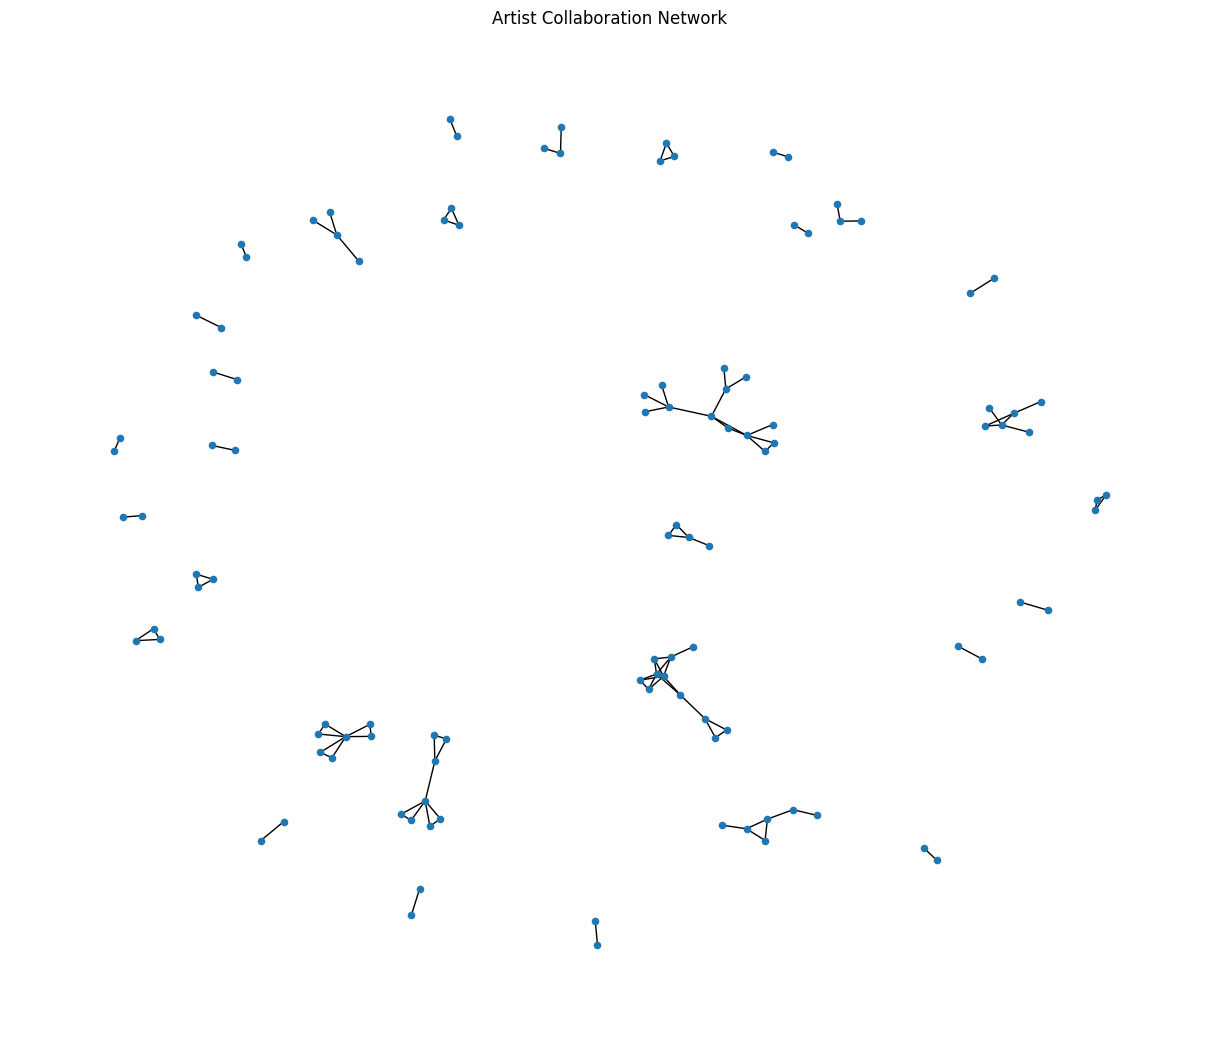

In [51]:
plt.figure(figsize=(12,10))

nx.draw(
    G,
    with_labels=False,
    node_size=20
)

plt.title("Artist Collaboration Network")

plt.show()